# R&E 연구 검증 방법론 1편: One Feature (단변량 분석)

변수 **하나**를 골라서 "이 변수가 어떻게 생겼는가?"를 파악하는 단계.
모든 분석의 출발점이며, 논문에서는 보통 **Table 1 (기술통계)**에 해당한다.

```
1-Feature
|
|-- 수치형 (Numeric)
|     |-- 기초: 기술통계, 히스토그램, 박스플롯
|     |-- 검정: 정규성 검정 (Shapiro-Wilk)
|     |-- 고급: KDE, 이상치 탐지, 분포 적합, 부트스트랩
|
|-- 범주형 (Categorical)
|     |-- 빈도표, 비율, 막대그래프
|
|-- 시계열 (Time Series)
      |-- 추세 시각화, 이동평균
      |-- 정상성 검정 (ADF test)
      |-- 자기상관 (ACF/PACF)
      |-- 시계열 분해 (Trend + Seasonal + Residual)
```

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

# Colab에서도 바로 로드 가능한 데이터셋
df = sns.load_dataset('penguins').dropna()
print(f'데이터 수: {len(df)}')
df.head()

데이터 수: 333


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


---
## 1-A. 수치형 변수: 기초 분석

수치형 변수 하나를 골랐을 때 가장 먼저 할 일.

| 방법 | 알 수 있는 것 | Python |
|------|-------------|--------|
| 기술통계 | 중심(mean, median), 퍼짐(std), 범위 | `df['col'].describe()` |
| 히스토그램 | 분포 모양, 치우침, 봉우리 수 | `plt.hist()` |
| 박스플롯 | 사분위수, 이상치 | `plt.boxplot()` |

### Agent 지시 예시
> "body_mass_g 변수의 기술통계를 구하고, 히스토그램과 박스플롯을 그려줘."


In [2]:
# 기술통계
target = df['body_mass_g']
print('=== body_mass_g 기술통계 ===')
print(f'  평균(mean):     {target.mean():.1f}')
print(f'  중앙값(median): {target.median():.1f}')
print(f'  표준편차(std):  {target.std():.1f}')
print(f'  최솟값(min):    {target.min():.1f}')
print(f'  최댓값(max):    {target.max():.1f}')
print(f'  왜도(skew):     {target.skew():.3f}')  # 0에 가까우면 대칭
print(f'  첨도(kurtosis): {target.kurtosis():.3f}')  # 0이면 정규분포와 유사

=== body_mass_g 기술통계 ===
  평균(mean):     4207.1
  중앙값(median): 4050.0
  표준편차(std):  805.2
  최솟값(min):    2700.0
  최댓값(max):    6300.0
  왜도(skew):     0.472
  첨도(kurtosis): -0.733


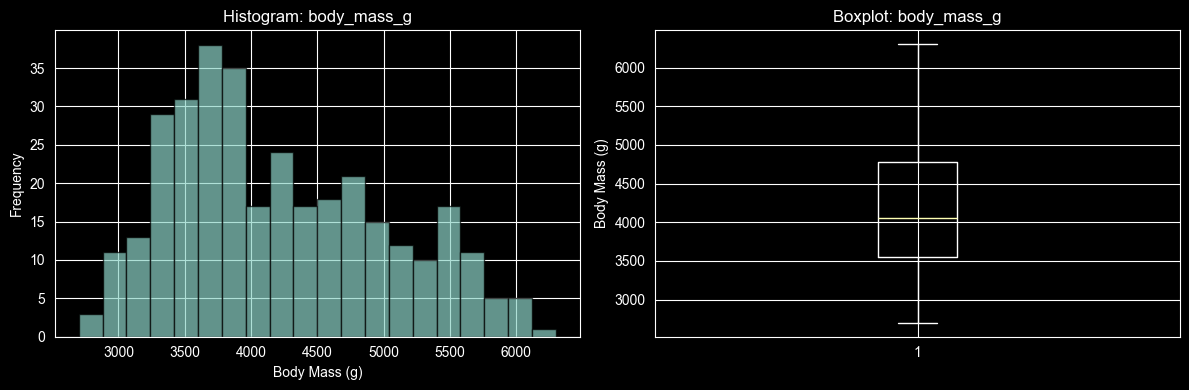

In [3]:
# 히스토그램 + 박스플롯
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(target, bins=20, edgecolor='black', alpha=0.7)
axes[0].set_title('Histogram: body_mass_g')
axes[0].set_xlabel('Body Mass (g)')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(target, vert=True)
axes[1].set_title('Boxplot: body_mass_g')
axes[1].set_ylabel('Body Mass (g)')

plt.tight_layout()
plt.show()

---
## 1-B. 정규성 검정

많은 통계 검정(t-test, ANOVA, Pearson 상관 등)은 **"데이터가 정규분포를 따른다"**는 가정 위에 만들어졌다.
이 가정이 맞는지 먼저 확인해야 한다.

| 검정 | 특징 | Python |
|------|------|--------|
| Shapiro-Wilk | 소표본(n<5000)에 강력. 가장 많이 사용 | `stats.shapiro(x)` |
| D'Agostino-Pearson | 왜도+첨도 결합 검정 | `stats.normaltest(x)` |
| Kolmogorov-Smirnov | 큰 표본에 적합, 분포 비교 범용 | `stats.kstest(x, 'norm')` |
| Anderson-Darling | 꼬리 부분에 민감 | `stats.anderson(x)` |

**해석**: p < 0.05 -> 정규분포가 아니다 (비모수 검정 사용)

| 정규분포 O | 정규분포 X (비모수 대안) |
|-----------|----------------------|
| t-test | Mann-Whitney U |
| ANOVA | Kruskal-Wallis |
| Pearson r | Spearman rho |


In [4]:
# 정규성 검정 3종
print('=== 정규성 검정: body_mass_g ===')
print()

# 1) Shapiro-Wilk (가장 많이 사용)
stat, p = stats.shapiro(target)
print(f'Shapiro-Wilk:       stat={stat:.4f}, p={p:.4f}')

# 2) D'Agostino-Pearson
stat2, p2 = stats.normaltest(target)
print(f"D'Agostino-Pearson: stat={stat2:.4f}, p={p2:.4f}")

# 3) Kolmogorov-Smirnov (정규분포와 비교)
# 표준화 후 표준정규분포와 비교
z = (target - target.mean()) / target.std()
stat3, p3 = stats.kstest(z, 'norm')
print(f'Kolmogorov-Smirnov: stat={stat3:.4f}, p={p3:.4f}')

print()
for name, pv in [('Shapiro-Wilk', p), ("D'Agostino", p2), ('K-S', p3)]:
    verdict = '정규분포 X' if pv < 0.05 else '정규분포 O'
    print(f'  {name:20s} -> {verdict} (p={pv:.4f})')

=== 정규성 검정: body_mass_g ===

Shapiro-Wilk:       stat=0.9580, p=0.0000
D'Agostino-Pearson: stat=30.4642, p=0.0000
Kolmogorov-Smirnov: stat=0.1057, p=0.0011

  Shapiro-Wilk         -> 정규분포 X (p=0.0000)
  D'Agostino           -> 정규분포 X (p=0.0000)
  K-S                  -> 정규분포 X (p=0.0011)


---
## 1-C. 고급 단변량: KDE, 이상치 탐지, 분포 적합

실제 연구에서는 히스토그램 너머의 분석이 필요하다.

| 방법 | 질문 | 핵심 |
|------|------|------|
| **KDE** (커널 밀도 추정) | 분포의 진짜 모양은? | 히스토그램의 연속 버전. 봉우리 수, 비대칭성 확인 |
| **이상치 탐지 (IQR)** | 비정상적 값이 있는가? | Q1-1.5*IQR ~ Q3+1.5*IQR 범위 밖 |
| **이상치 탐지 (Z-score)** | 평균에서 극단적으로 먼 값? | \|z\| > 3이면 이상치 의심 |
| **분포 적합** | 어떤 이론적 분포를 따르는가? | 정규, 로그정규, 감마 등에 fitting |
| **부트스트랩** | 추정치의 신뢰구간은? | 반복 재추출로 불확실성 계산 |

### Agent 지시 예시
> "body_mass_g의 KDE를 그리고, IQR과 Z-score로 이상치를 찾아줘.
> 정규분포, 로그정규분포, 감마분포 중 어느 것에 가장 잘 맞는지도 확인해줘."


### 주요 확률 분포와 데이터의 성격

"내 데이터가 어떤 분포를 따르는가?"를 아는 것은 단순한 수학이 아니다.
**데이터가 어떤 분포를 따르는지는 그 데이터가 어떤 메커니즘으로 생성되었는지를 반영한다.**

---

#### 연속형 분포

| 분포 | 모양 | 어떤 데이터가 이 분포를 따르는가 | 실제 예시 |
|------|------|-------------------------------|----------|
| **정규분포** (Normal) | 좌우 대칭 종형 | 수많은 독립적 요인이 **더해져서** 만들어진 값. 중심극한정리에 의해 표본 평균은 항상 정규분포에 수렴 | 키, 체중, 시험 점수, 측정 오차, 제조 공차 |
| **로그정규분포** (Log-Normal) | 오른쪽 꼬리가 긴 비대칭 | 수많은 독립적 요인이 **곱해져서** 만들어진 값. log를 취하면 정규분포가 됨 | 소득 분포, 주가 수익률의 누적, 도시 인구, 세포 크기, 입자 크기 |
| **지수분포** (Exponential) | 0에서 시작해 급감소 | **다음 사건까지의 대기 시간**. 사건이 일정한 확률로 독립적으로 발생할 때 | 고장까지 시간, 고객 도착 간격, 방사성 붕괴, 전화 통화 간격 |
| **감마분포** (Gamma) | 오른쪽 꼬리, 유연한 모양 | 지수분포의 일반화. **K번째 사건까지의 대기 시간** 또는 양(+)의 연속 측정값 | 보험 청구 금액, 강우량, 대기 시간 합산, 서비스 시간 |
| **베타분포** (Beta) | 0~1 사이, 다양한 모양 | **비율, 확률, 비중** 등 0과 1 사이에 한정된 값 | 합격률, 전환율, 유전자 빈도, 야구 타율 |
| **균일분포** (Uniform) | 평평한 직사각형 | 모든 값이 **동등한 확률**로 나타남. 특별한 편향이 없는 무작위 | 난수 생성, 주사위(이산), 룰렛 |
| **와이블분포** (Weibull) | 감마와 유사, 유연 | **수명/생존 데이터**. 고장률이 시간에 따라 변할 수 있음 | 부품 수명, 재료 파괴 강도, 풍속 분포 |
| **코시분포** (Cauchy/t with df=1) | 매우 무거운 꼬리 | **극단값이 자주** 나타나는 데이터. 평균이 존재하지 않음 | 금융 위기 시 수익률, 공진 주파수, 비율 추정 |
| **t-분포** (Student's t) | 정규와 유사하나 꼬리 두꺼움 | **소표본**에서의 추정. 자유도가 커지면 정규분포에 수렴 | 소표본 평균 검정, 회귀 계수의 분포 |
| **파레토분포** (Pareto) | 극단적 꼬리 (멱법칙) | **소수가 대부분을 차지**하는 불균형 데이터. 80/20 법칙 | 부의 분포, 도시 크기, 웹 트래픽, 지진 규모 |

#### 이산형 분포

| 분포 | 어떤 데이터가 이 분포를 따르는가 | 실제 예시 |
|------|-------------------------------|----------|
| **이항분포** (Binomial) | n번 시행에서 **성공 횟수** (각 시행은 독립, 성공 확률 동일) | 불량품 수, 합격자 수, 동전 앞면 횟수 |
| **포아송분포** (Poisson) | 단위 시간/공간당 **사건 발생 횟수** (드물게 독립적으로 발생) | 시간당 방문자 수, 페이지당 오타, 연간 지진 횟수 |
| **기하분포** (Geometric) | **첫 번째 성공까지의 시행 횟수** | 첫 불량까지 검사 횟수, 첫 당첨까지 복권 구매 |
| **음이항분포** (Negative Binomial) | **K번째 성공까지의 시행 횟수**. 포아송보다 분산이 클 때 대안 | 과분산된 카운트 데이터, 유전자 발현량 |

---

#### 분포 선택의 실전 가이드

```
내 데이터의 성격은?
|
|-- 양수만 가능 (0 이상)
|     |-- 대기 시간, 수명 -> 지수분포, 와이블분포
|     |-- 금액, 크기 (오른쪽 꼬리) -> 로그정규분포, 감마분포
|     |-- 극단적 불균형 (소수가 대부분) -> 파레토분포
|     |-- 비율 (0~1 사이) -> 베타분포
|     |-- 횟수 (정수) -> 포아송분포, 이항분포
|
|-- 음수도 가능
|     |-- 대칭적, 합산 결과 -> 정규분포
|     |-- 소표본 -> t-분포
|     |-- 극단값 빈번 -> 코시분포
|
|-- 판단 방법
      |-- 히스토그램/KDE -> 모양 확인
      |-- QQ-plot -> 특정 분포와 비교
      |-- 분포 적합 (AIC, KS test) -> 정량적 비교
```

#### 핵심: 왜 분포를 아는 것이 중요한가?

1. **적절한 통계 검정 선택**: 정규분포가 아니면 비모수 검정을 써야 한다
2. **모델링 근거**: "왜 이 모델을 선택했는가?"에 이론적 답을 줄 수 있다
3. **이상치 판단 기준**: 분포를 알아야 "비정상적인 값"의 기준을 세울 수 있다
4. **시뮬레이션**: 분포를 알면 유사한 데이터를 인공으로 생성할 수 있다
5. **현상 이해**: 데이터의 생성 메커니즘에 대한 단서가 된다

> **연구에서 자주 만나는 패턴**:
> - "오른쪽으로 꼬리가 길다" -> 로그 변환 시도 -> 로그정규 가능성
> - "0 근처에 몰려있고 가끔 큰 값" -> 지수/감마
> - "종 모양이지만 꼬리가 두껍다" -> t-분포 (자유도 추정)
> - "수익률이 정규분포 가정보다 극단값이 잦다" -> 코시 또는 t-분포


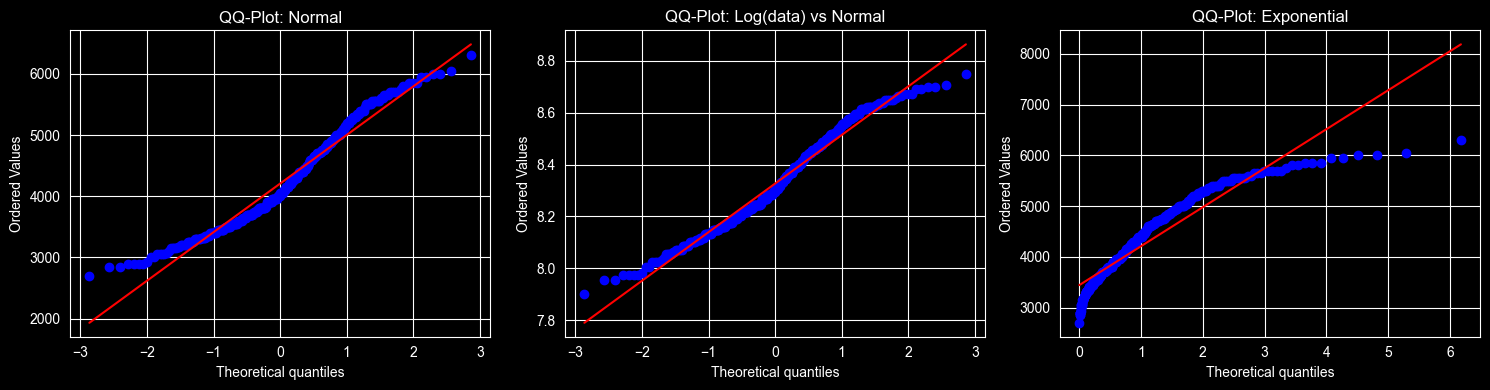

QQ-Plot 읽는 법:
  - 점들이 빨간 대각선에 가까움 -> 해당 분포와 잘 맞음
  - 끝부분이 휘어짐 -> 꼬리가 이론 분포보다 두껍거나 얇음
  - S자 형태 -> 왜도(skewness)가 있음


In [5]:
# QQ-Plot: 데이터가 특정 분포를 따르는지 시각적으로 확인
# 점들이 대각선에 가까울수록 해당 분포와 일치
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1) 정규분포 QQ-plot
stats.probplot(target, dist='norm', plot=axes[0])
axes[0].set_title('QQ-Plot: Normal')

# 2) 로그정규 확인 (log 변환 후 정규 QQ)
stats.probplot(np.log(target), dist='norm', plot=axes[1])
axes[1].set_title('QQ-Plot: Log(data) vs Normal')

# 3) 지수분포 QQ-plot
stats.probplot(target, dist='expon', plot=axes[2])
axes[2].set_title('QQ-Plot: Exponential')

plt.tight_layout()
plt.show()

print('QQ-Plot 읽는 법:')
print('  - 점들이 빨간 대각선에 가까움 -> 해당 분포와 잘 맞음')
print('  - 끝부분이 휘어짐 -> 꼬리가 이론 분포보다 두껍거나 얇음')
print('  - S자 형태 -> 왜도(skewness)가 있음')

C:\Users\catac\AppData\Local\Temp\ipykernel_122200\3632339736.py:33: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) Arial.
  plt.tight_layout()
C:\ProgramData\miniconda3\envs\py310\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


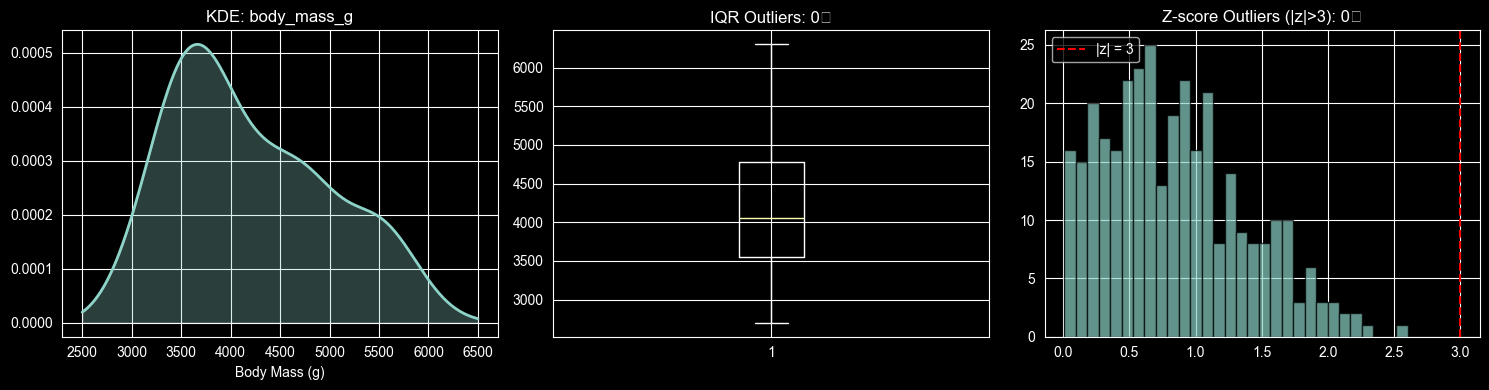

IQR 정상 범위: [1712, 6612]
IQR 이상치: 0개
Z-score 이상치 (|z|>3): 0개


In [6]:
# KDE: 분포의 연속적 모양
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1) KDE
kde = gaussian_kde(target)
x_range = np.linspace(target.min() - 200, target.max() + 200, 300)
axes[0].plot(x_range, kde(x_range), linewidth=2)
axes[0].fill_between(x_range, kde(x_range), alpha=0.3)
axes[0].set_title('KDE: body_mass_g')
axes[0].set_xlabel('Body Mass (g)')

# 2) 이상치: IQR
Q1, Q3 = target.quantile(0.25), target.quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
outliers_iqr = target[(target < lower) | (target > upper)]

axes[1].boxplot(target, vert=True)
if len(outliers_iqr) > 0:
    axes[1].scatter([1]*len(outliers_iqr), outliers_iqr, color='red', zorder=5, s=50)
axes[1].set_title(f'IQR Outliers: {len(outliers_iqr)}개')

# 3) 이상치: Z-score
z_scores = np.abs(stats.zscore(target))
outliers_z = target[z_scores > 3]
axes[2].hist(z_scores, bins=30, edgecolor='black', alpha=0.7)
axes[2].axvline(x=3, color='red', linestyle='--', label='|z| = 3')
axes[2].set_title(f'Z-score Outliers (|z|>3): {len(outliers_z)}개')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f'IQR 정상 범위: [{lower:.0f}, {upper:.0f}]')
print(f'IQR 이상치: {len(outliers_iqr)}개')
print(f'Z-score 이상치 (|z|>3): {len(outliers_z)}개')

=== 분포 적합 비교 (AIC 기준, 낮을수록 좋음) ===

  Normal      : AIC=5404.3, KS p-value=0.0010
  Log-Normal  : AIC=5378.2, KS p-value=0.1731
  Gamma       : AIC=5373.2, KS p-value=0.2458


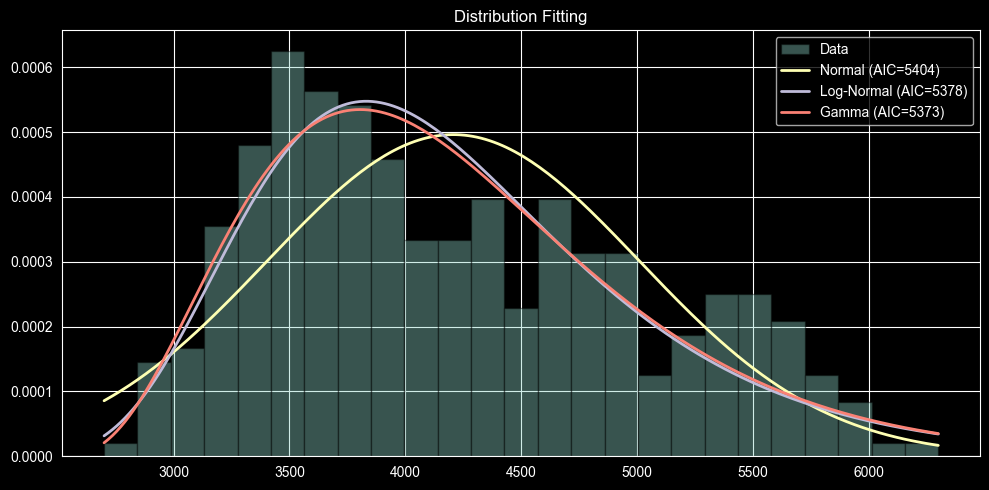


  -> 가장 적합한 분포: Gamma (AIC=5373.2)


In [7]:
# 분포 적합 (Distribution Fitting)
# 데이터가 어떤 이론적 분포를 따르는지 비교

from scipy.stats import norm, lognorm, gamma

distributions = {
    'Normal': norm,
    'Log-Normal': lognorm,
    'Gamma': gamma
}

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(target, bins=25, density=True, alpha=0.4, edgecolor='black', label='Data')

print('=== 분포 적합 비교 (AIC 기준, 낮을수록 좋음) ===')
print()
results = []
for name, dist in distributions.items():
    params = dist.fit(target)
    # KS 검정: 적합도
    ks_stat, ks_p = stats.kstest(target, dist.cdf, args=params)
    # AIC 근사: -2*loglik + 2*k
    loglik = np.sum(dist.logpdf(target, *params))
    aic = -2 * loglik + 2 * len(params)
    results.append((name, aic, ks_p))

    x = np.linspace(target.min(), target.max(), 200)
    ax.plot(x, dist.pdf(x, *params), linewidth=2, label=f'{name} (AIC={aic:.0f})')
    print(f'  {name:12s}: AIC={aic:.1f}, KS p-value={ks_p:.4f}')

ax.legend()
ax.set_title('Distribution Fitting')
plt.tight_layout()
plt.show()

best = min(results, key=lambda x: x[1])
print(f'\n  -> 가장 적합한 분포: {best[0]} (AIC={best[1]:.1f})')

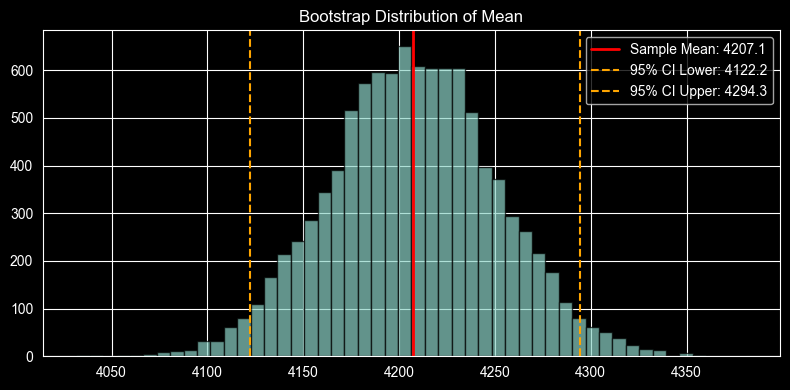

표본 평균: 4207.1g
95% 부트스트랩 신뢰구간: [4122.2, 4294.3]g


In [8]:
# 부트스트랩 신뢰구간
# "평균이 정확히 4207g이다"보다 "95% 신뢰구간은 [4100, 4310]이다"가 더 과학적
np.random.seed(42)
n_boot = 10000
boot_means = [np.random.choice(target, size=len(target), replace=True).mean()
              for _ in range(n_boot)]

ci_lower = np.percentile(boot_means, 2.5)
ci_upper = np.percentile(boot_means, 97.5)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(boot_means, bins=50, edgecolor='black', alpha=0.7)
ax.axvline(target.mean(), color='red', linewidth=2, label=f'Sample Mean: {target.mean():.1f}')
ax.axvline(ci_lower, color='orange', linestyle='--', label=f'95% CI Lower: {ci_lower:.1f}')
ax.axvline(ci_upper, color='orange', linestyle='--', label=f'95% CI Upper: {ci_upper:.1f}')
ax.legend()
ax.set_title('Bootstrap Distribution of Mean')
plt.tight_layout()
plt.show()

print(f'표본 평균: {target.mean():.1f}g')
print(f'95% 부트스트랩 신뢰구간: [{ci_lower:.1f}, {ci_upper:.1f}]g')

---
## 1-D. 범주형 변수

범주형 변수 하나를 골랐을 때 할 수 있는 것들.

| 방법 | 알 수 있는 것 |
|------|-------------|
| 빈도표 | 각 범주에 몇 개씩 있는가 |
| 비율 | 전체에서 각 범주의 비중 |
| 막대그래프 | 빈도의 시각적 비교 |
| 최빈값 (mode) | 가장 많은 범주 |

### Agent 지시 예시
> "species 변수의 빈도와 비율을 구하고, 막대그래프로 그려줘."


=== species 빈도/비율 ===
            빈도     비율
species              
Adelie     146  43.8%
Gentoo     119  35.7%
Chinstrap   68  20.4%



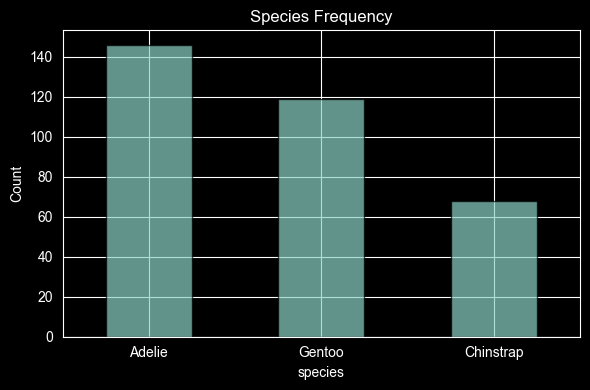

In [9]:
# 범주형 분석
freq = df['species'].value_counts()
ratio = df['species'].value_counts(normalize=True)

summary = pd.DataFrame({
    '빈도': freq,
    '비율': ratio.map(lambda x: f'{x:.1%}')
})
print('=== species 빈도/비율 ===')
print(summary)
print()

plt.figure(figsize=(6, 4))
freq.plot(kind='bar', edgecolor='black', alpha=0.7)
plt.title('Species Frequency')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

---
## 1-E. 시계열 단변량 분석

시간 축을 가진 수치형 변수 1개에 대한 분석.
**주가, 온도, 센서값** 등 시간에 따라 변하는 데이터에 적용한다.

| 방법 | 질문 | Python |
|------|------|--------|
| 시계열 플롯 + 이동평균 | 추세가 있는가? | `pd.Series.rolling().mean()` |
| ADF 검정 (정상성) | 통계적 성질이 시간에 따라 변하는가? | `from statsmodels.tsa.stattools import adfuller` |
| ACF / PACF | 과거 값과 자기 자신이 상관이 있는가? | `from statsmodels.graphics.tsaplots import plot_acf` |
| 시계열 분해 | 추세 + 계절성 + 잔차로 분리 | `from statsmodels.tsa.seasonal import seasonal_decompose` |

### 핵심 개념: 정상성 (Stationarity)
- **정상(stationary)**: 평균과 분산이 시간에 따라 일정 -> 분석/예측 가능
- **비정상(non-stationary)**: 추세나 계절성이 있음 -> 차분(differencing)으로 정상화 필요
- 대부분의 시계열 모델(ARIMA 등)은 정상성을 가정한다

### Agent 지시 예시
> "이 시계열 데이터의 추세를 시각화하고 20일 이동평균을 그려줘.
> ADF 검정으로 정상성을 확인하고, ACF/PACF 플롯도 그려줘.
> 비정상이면 1차 차분 후 다시 ADF 검정해줘."


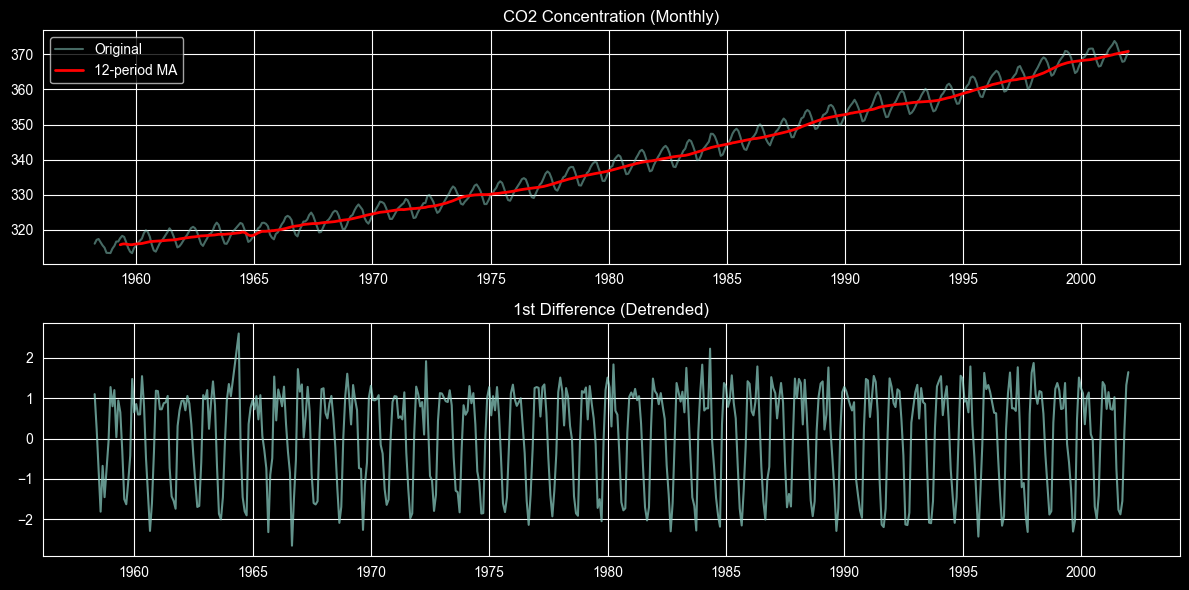

In [16]:
# 시계열 예시 데이터: 항공 승객 수
# Colab에서도 바로 사용 가능한 내장 데이터

# statsmodels에서 예시 데이터 로드
try:
    from statsmodels.datasets import co2
    ts = co2.load().data
    ts = ts.resample('ME').mean().dropna()  # 월별 평균
    ts_col = 'co2'
    ts_title = 'CO2 Concentration (Monthly)'
except:
    # 대안: 랜덤 시계열
    np.random.seed(42)
    dates = pd.date_range('2020-01-01', periods=200, freq='D')
    trend = np.linspace(0, 10, 200)
    seasonal = 5 * np.sin(np.arange(200) * 2 * np.pi / 30)
    noise = np.random.normal(0, 1, 200)
    ts = pd.DataFrame({'value': trend + seasonal + noise}, index=dates)
    ts_col = 'value'
    ts_title = 'Synthetic Time Series'

fig, axes = plt.subplots(2, 1, figsize=(12, 6))

# 원본 + 이동평균
axes[0].plot(ts, alpha=0.5, label='Original')
axes[0].plot(ts.rolling(12).mean(), color='red', linewidth=2, label='12-period MA')
axes[0].set_title(ts_title)
axes[0].legend()

# 1차 차분
diff = ts.diff().dropna()
axes[1].plot(diff, alpha=0.7)
axes[1].set_title('1st Difference (Detrended)')

plt.tight_layout()
plt.show()

In [18]:
# ADF 정상성 검정
from statsmodels.tsa.stattools import adfuller

def adf_test(series, name=''):
    result = adfuller(series.dropna(), autolag='AIC')
    print(f'=== ADF Test: {name} ===')
    print(f'  ADF Statistic: {result[0]:.4f}')
    print(f'  p-value:       {result[1]:.4f}')
    print(f'  Critical Values:')
    for key, val in result[4].items():
        print(f'    {key}: {val:.4f}')
    if result[1] < 0.05:
        print('  -> 정상(Stationary): 추세 없음')
    else:
        print('  -> 비정상(Non-stationary): 추세 있음 -> 차분 필요')
    print()

# 원본
values = ts.iloc[:, 0] if hasattr(ts, 'iloc') else ts
adf_test(values, 'Original')

# 1차 차분 후
adf_test(values.diff().dropna(), '1st Difference')

=== ADF Test: Original ===
  ADF Statistic: 3.3639
  p-value:       1.0000
  Critical Values:
    1%: -3.4433
    5%: -2.8672
    10%: -2.5698
  -> 비정상(Non-stationary): 추세 있음 -> 차분 필요

=== ADF Test: 1st Difference ===
  ADF Statistic: -4.7249
  p-value:       0.0001
  Critical Values:
    1%: -3.4434
    5%: -2.8673
    10%: -2.5698
  -> 정상(Stationary): 추세 없음



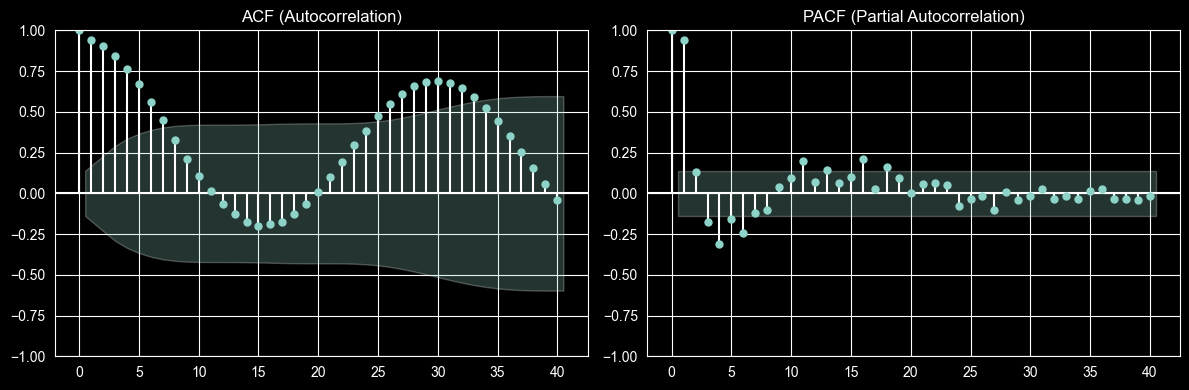

ACF 읽는 법:
  - 천천히 감소 -> 비정상 (차분 필요)
  - 특정 lag에서 급격히 끊김 -> MA(q) 모델 후보

PACF 읽는 법:
  - 특정 lag에서 급격히 끊김 -> AR(p) 모델 후보


In [13]:
# ACF / PACF
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(values.dropna(), lags=40, ax=axes[0])
axes[0].set_title('ACF (Autocorrelation)')

plot_pacf(values.dropna(), lags=40, ax=axes[1], method='ywm')
axes[1].set_title('PACF (Partial Autocorrelation)')

plt.tight_layout()
plt.show()

print('ACF 읽는 법:')
print('  - 천천히 감소 -> 비정상 (차분 필요)')
print('  - 특정 lag에서 급격히 끊김 -> MA(q) 모델 후보')
print()
print('PACF 읽는 법:')
print('  - 특정 lag에서 급격히 끊김 -> AR(p) 모델 후보')

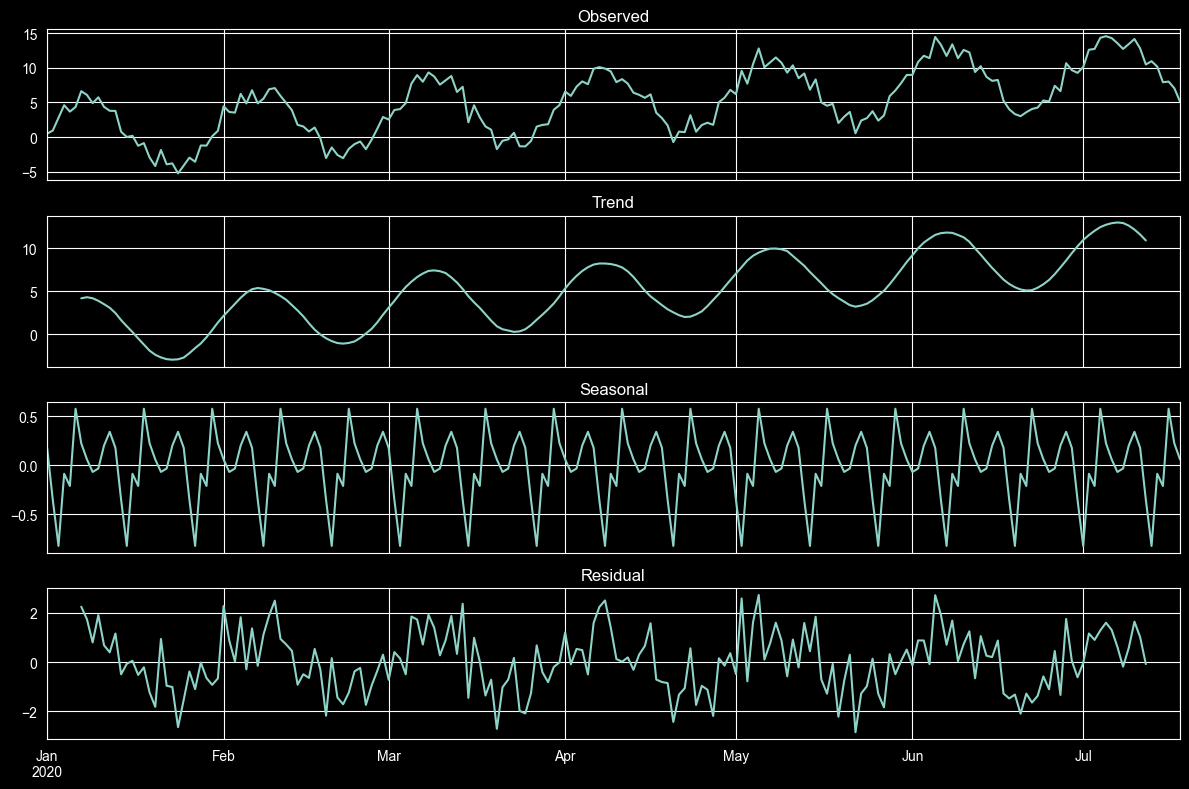

분해 결과 해석:
  - Trend: 장기적 방향 (상승? 하락? 일정?)
  - Seasonal: 반복 패턴 (주기가 있는가?)
  - Residual: 추세/계절성 제거 후 남은 잔차 (랜덤이면 좋음)


In [14]:
# 시계열 분해: Trend + Seasonal + Residual
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(values.dropna(), model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
decomp.observed.plot(ax=axes[0], title='Observed')
decomp.trend.plot(ax=axes[1], title='Trend')
decomp.seasonal.plot(ax=axes[2], title='Seasonal')
decomp.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

print('분해 결과 해석:')
print('  - Trend: 장기적 방향 (상승? 하락? 일정?)')
print('  - Seasonal: 반복 패턴 (주기가 있는가?)')
print('  - Residual: 추세/계절성 제거 후 남은 잔차 (랜덤이면 좋음)')

---
## 1편 요약: 단변량 분석 체크리스트

### 수치형 변수
1. **기술통계** (mean, median, std, min, max, skew, kurtosis)
2. **시각화** (히스토그램, 박스플롯, KDE)
3. **정규성 검정** (Shapiro-Wilk) -> 이후 검정 방법 결정
4. **이상치 탐지** (IQR 또는 Z-score) -> 제거 여부 판단
5. **분포 적합** (어떤 이론적 분포와 유사한가?)
6. **신뢰구간** (부트스트랩 또는 t-분포 기반)

### 범주형 변수
1. **빈도표** + **비율**
2. **막대그래프**

### 시계열 변수
1. **시계열 플롯** + 이동평균
2. **ADF 검정** (정상성 확인)
3. **ACF/PACF** (자기상관 구조)
4. **시계열 분해** (추세 + 계절성 + 잔차)

### Agent 통합 지시 예시
> "이 데이터의 [변수명]에 대해 단변량 분석을 수행해줘:
> 1) 기술통계와 분포 시각화 (히스토그램, 박스플롯, KDE)
> 2) 정규성 검정 (Shapiro-Wilk)
> 3) 이상치 탐지 (IQR, Z-score)
> 4) 결과를 표로 정리해줘."
